In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("--- Observation Book Dummy Problem ---")
data = {
    'Age': [18, 23, 24, 41, 43, 38],
    'SalaryK': [50, 55, 70, 60, 70, 40],
    'Target': ['N', 'N', 'N', 'Y', 'Y', 'Y']
}
df_dummy = pd.DataFrame(data)

X_dummy = df_dummy[['Age', 'SalaryK']]
y_dummy = df_dummy['Target']


knn_dummy = KNeighborsClassifier(n_neighbors=3)
knn_dummy.fit(X_dummy, y_dummy)


X_test_dummy = pd.DataFrame({'Age': [35], 'SalaryK': [100]})
pred_dummy = knn_dummy.predict(X_test_dummy)
print(f"Predicted Target for (Age=35, SalaryK=100) with K=3: {pred_dummy[0]}\n")

--- Observation Book Dummy Problem ---
Predicted Target for (Age=35, SalaryK=100) with K=3: Y



--- Task 1: Iris Dataset ---
Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



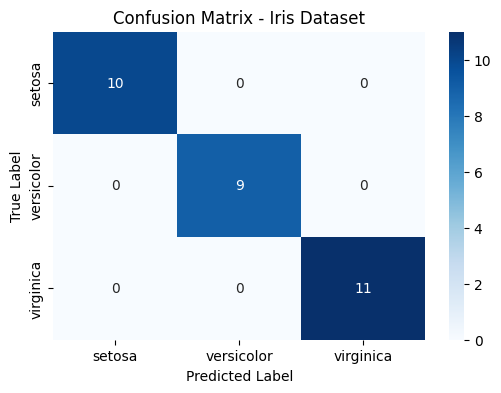

In [2]:
# ---------------------------------------------------------
# TASK 1: IRIS DATASET
# ---------------------------------------------------------
print("--- Task 1: Iris Dataset ---")
# Load dataset
iris_df = pd.read_csv('iris (1).csv')

# Separate features and target
X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

# 80% training and 20% testing
X_train_ir, X_test_ir, y_train_ir, y_test_ir = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Build KNN classifier (choosing K=5 as an appropriate starting point)
knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(X_train_ir, y_train_ir)

# Predictions
y_pred_ir = knn_iris.predict(X_test_ir)

# Display Scores
print("Accuracy Score:", accuracy_score(y_test_ir, y_pred_ir))
print("\nClassification Report:\n", classification_report(y_test_ir, y_pred_ir))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
cm_ir = confusion_matrix(y_test_ir, y_pred_ir)
sns.heatmap(cm_ir, annot=True, fmt='d', cmap='Blues', xticklabels=knn_iris.classes_, yticklabels=knn_iris.classes_)
plt.title('Confusion Matrix - Iris Dataset')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


--- Task 2: Diabetes Dataset ---
Accuracy Score: 0.6818181818181818


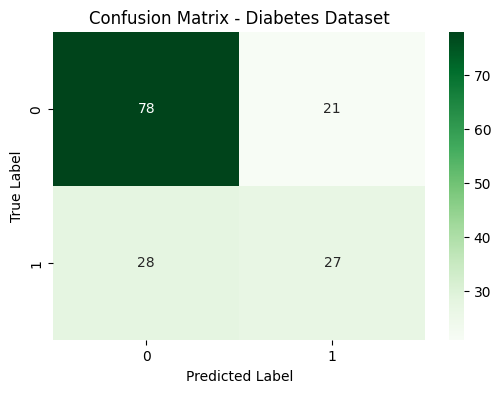

In [3]:
# ---------------------------------------------------------
# TASK 2: DIABETES DATASET
# ---------------------------------------------------------
print("\n--- Task 2: Diabetes Dataset ---")
# Load dataset
diabetes_df = pd.read_csv('diabetes.csv')

# Separate features and target
X_diab = diabetes_df.drop('Outcome', axis=1)
y_diab = diabetes_df['Outcome']

# 80% training and 20% testing
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

# Perform Feature Scaling (Crucial for KNN on datasets with varying scales like diabetes)
scaler = StandardScaler()
X_train_d_scaled = scaler.fit_transform(X_train_d)
X_test_d_scaled = scaler.transform(X_test_d)

# Build KNN classifier
knn_diab = KNeighborsClassifier(n_neighbors=7) # Choosing an arbitrary K
knn_diab.fit(X_train_d_scaled, y_train_d)

# Predictions
y_pred_d = knn_diab.predict(X_test_d_scaled)

# Display Scores
print("Accuracy Score:", accuracy_score(y_test_d, y_pred_d))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
cm_d = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Diabetes Dataset')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


--- Task 3: Heart Dataset ---
Optimal Value of K found: 7 with an accuracy of 0.9180


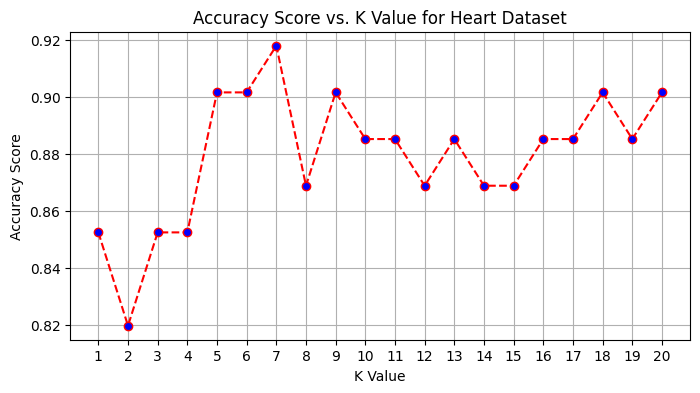


Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



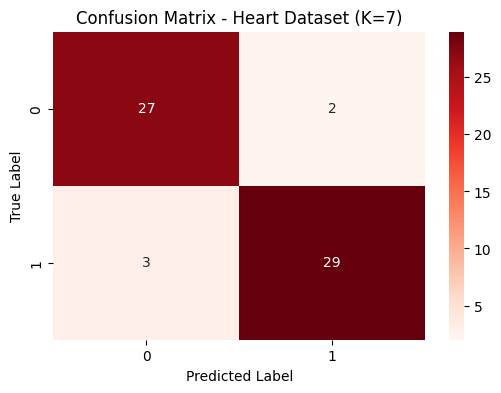

In [4]:
# ---------------------------------------------------------
# TASK 3: HEART DATASET (Find optimal K)
# ---------------------------------------------------------
print("\n--- Task 3: Heart Dataset ---")
# Load dataset
heart_df = pd.read_csv('heart.csv')

# Separate features and target
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 80% training and 20% testing
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# Feature scaling
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

# Figure out the value of K that gives the maximum score
k_values = range(1, 21)
scores = []
best_k = 1
best_score = 0

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_h_scaled, y_train_h)
    score = knn_temp.score(X_test_h_scaled, y_test_h)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal Value of K found: {best_k} with an accuracy of {best_score:.4f}")

# Plot Accuracy vs K Value
plt.figure(figsize=(8,4))
plt.plot(k_values, scores, marker='o', linestyle='dashed', color='red', markerfacecolor='blue')
plt.title('Accuracy Score vs. K Value for Heart Dataset')
plt.xlabel('K Value')
plt.ylabel('Accuracy Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Retrain model using the best K
knn_heart_best = KNeighborsClassifier(n_neighbors=best_k)
knn_heart_best.fit(X_train_h_scaled, y_train_h)
y_pred_h = knn_heart_best.predict(X_test_h_scaled)

print("\nClassification Report:\n", classification_report(y_test_h, y_pred_h))

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
cm_h = confusion_matrix(y_test_h, y_pred_h)
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix - Heart Dataset (K={best_k})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

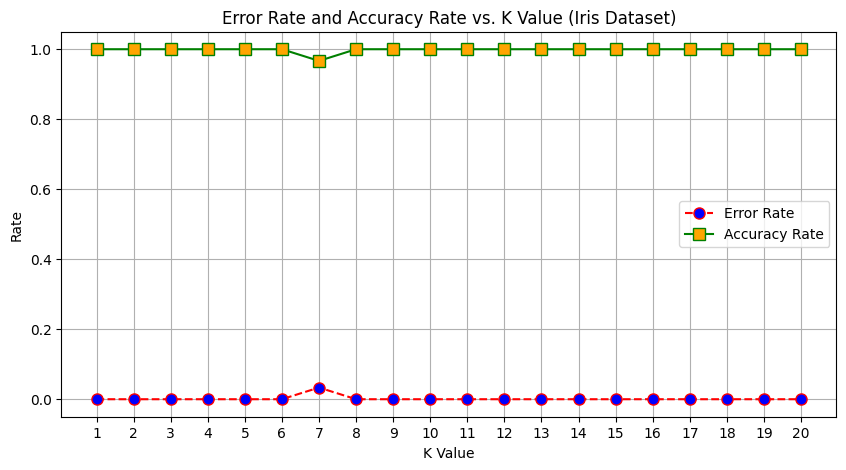

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Assuming X_train_ir, X_test_ir, y_train_ir, y_test_ir are already defined from Task 1

k_values = range(1, 21)
accuracy_rates = []
error_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_ir, y_train_ir)
    y_pred = knn.predict(X_test_ir)

    acc = accuracy_score(y_test_ir, y_pred)
    accuracy_rates.append(acc)
    error_rates.append(1 - acc) # Error rate calculation

# Plotting the results
plt.figure(figsize=(10, 5))

# Plot Error Rate
plt.plot(k_values, error_rates, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=8, label='Error Rate')

# Plot Accuracy Rate
plt.plot(k_values, accuracy_rates, color='green', linestyle='-', marker='s',
         markerfacecolor='orange', markersize=8, label='Accuracy Rate')

plt.title('Error Rate and Accuracy Rate vs. K Value (Iris Dataset)')
plt.xlabel('K Value')
plt.ylabel('Rate')
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Fit the scaler on the TRAINING data ONLY, and transform it
X_train_scaled = scaler.fit_transform(X_train_d)

# 3. Transform the TEST data using the rules learned from the training data
X_test_scaled = scaler.transform(X_test_d)